
<h1 style="text-align: center;">CIÊNCIA DE DADOS</h1>
<h1 style="text-align: center;">Roteiro de Atividade Prática</h1>
<br>
<br>

Nome: ______________________________________________________________________________________      

Turma: ______________


**Componente:** Inteligência Artificial 
<br>
**Unidade Curricular:** Redes Neurais
<br>
**Tema da Semana:** Overfitting e Regularização
<br>


# Aula 2: Introdução à regularização

## Tarefa

- Se as bibliotecas não tiverem instaladas, instale-as.

- Acompanhe as instruções.

- Preencha o código onde está #TO DO

- Execute o código.

- Responda as perguntas e conclua a atividade


### Instalação das dependência do tensorflow

In [1]:
#!pip install --upgrade pip setuptools wheel

In [2]:
#!pip install tensorflow

In [3]:
#!conda install anaconda::tensorflow

In [4]:
#!pip install scikit-learn numpy pandas matplotlib

### Imports de dependências

In [19]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras import backend as K

In [6]:
# Limpar o estado do backend do TensorFlow
K.clear_session()

### Configurações

In [20]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

### Leitura dos dados

In [21]:
penguins = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv')

# Remover valores nulos
penguins.dropna(inplace=True)

In [22]:
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
y = penguins['species'].values

### Ajuste de classes para inteiros

In [23]:
encoder = OneHotEncoder(sparse=False)
y = encoder.fit_transform(y.reshape(-1, 1))

/home/fabiojanes/.local/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Normalização de dados numéricos

In [24]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Divisão do conjunto de dados em treino e teste

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

### Criação o modelo
#### Escolha um método de regularização (L1, L2 ou Dropout) e aplique na Rede Neural
##### L1  
model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l1(0.3)))

##### L2
model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.8)))

##### Dropout
model.add(Dense(16, activation='relu'))  
model.add(Dropout(0.3))

In [26]:
K.clear_session()
model = Sequential()

# Definição da forma de entrada
input_shape = (4,)

# Camada de entrada
model.add(Input(shape=input_shape))

#TO DO
#model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l1(0.3))) # para aplicar L1 apague a camada sem regularização acima

#model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.8))) # para aplicar L2 apague a camada sem regularização acima

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

#TO DO
#model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l1(0.3))) # para aplicar L1 apague a camada sem regularização acima

#model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.8))) # para aplicar L2 apague a camada sem regularização acima

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))


# Camada de saída
model.add(Dense(3, activation='softmax'))

In [27]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy', Precision(), Recall()])

In [28]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

### Treinamento do modelo

In [29]:
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2,  callbacks=[early_stopping])

Epoch 1/25
7/7 [==============================] - 0s 32ms/step - loss: 0.9864 - accuracy: 0.4717 - precision: 0.8039 - recall: 0.1934 - val_loss: 0.9523 - val_accuracy: 0.5370 - val_precision: 1.0000 - val_recall: 0.2222
Epoch 2/25
7/7 [==============================] - 0s 3ms/step - loss: 0.9660 - accuracy: 0.4670 - precision: 0.7273 - recall: 0.1887 - val_loss: 0.8972 - val_accuracy: 0.6852 - val_precision: 1.0000 - val_recall: 0.2407
Epoch 3/25
7/7 [==============================] - 0s 3ms/step - loss: 0.8970 - accuracy: 0.5330 - precision: 0.8571 - recall: 0.2264 - val_loss: 0.8476 - val_accuracy: 0.6667 - val_precision: 1.0000 - val_recall: 0.2407
Epoch 4/25
7/7 [==============================] - 0s 3ms/step - loss: 0.8596 - accuracy: 0.6604 - precision: 0.9180 - recall: 0.2642 - val_loss: 0.8012 - val_accuracy: 0.7778 - val_precision: 1.0000 - val_recall: 0.2593
Epoch 5/25
7/7 [==============================] - 0s 3ms/step - loss: 0.8224 - accuracy: 0.6604 - precision: 0.9697 - r

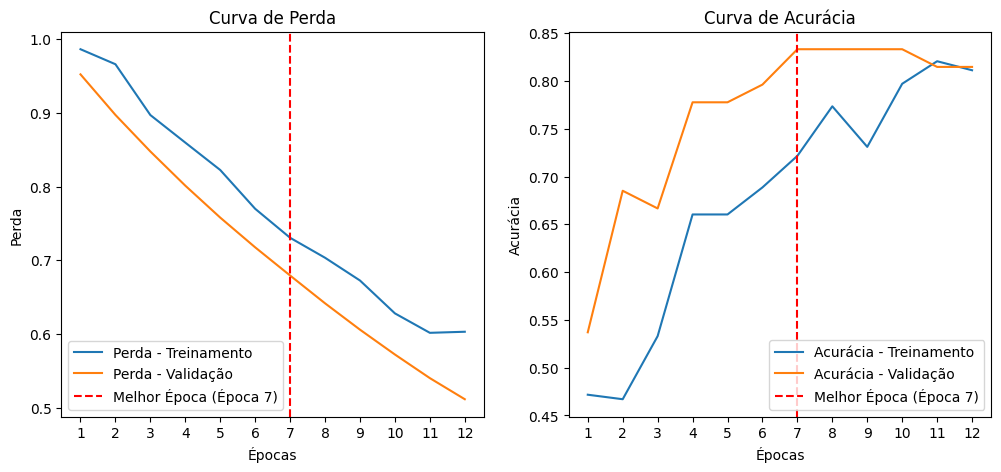

In [30]:
best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1

plt.figure(figsize=(12, 5))

epochs = range(1, len(history.history['loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], label='Perda - Treinamento')
plt.plot(epochs, history.history['val_loss'], label='Perda - Validação')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Melhor Época (Época {best_epoch})')
plt.title('Curva de Perda')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.xticks(epochs)

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], label='Acurácia - Treinamento')
plt.plot(epochs, history.history['val_accuracy'], label='Acurácia - Validação')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Melhor Época (Época {best_epoch})')
plt.title('Curva de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.xticks(epochs)

plt.show()

In [18]:
best_val_loss = history.history['val_loss'][best_epoch-1]
best_val_accuracy = history.history['val_accuracy'][best_epoch-1]
best_val_precision = history.history['val_precision'][best_epoch -1]
best_val_recall = history.history['val_recall'][best_epoch -1]

print(f"Melhor Época: {best_epoch}")
print(f"val_loss: {best_val_loss:.4f}")
print(f"val_accuracy: {best_val_accuracy:.4f}")
print(f"val_precision: {best_val_precision:.4f}")
print(f"val_recall: {best_val_recall:.4f}")

Melhor Época: 7
val_loss: 0.6792
val_accuracy: 0.8333
val_precision: 1.0000
val_recall: 0.4444


### Perguntas e Conclusão

##### Qual foi o método de regularização escolhido?
##### Quais os valores das métricas loss e acurácia?
##### A rede apresenta overfitting? (olhando a perda e acurácia de treinamento e validação na melhor época)